# Celsius to Fahrenheit (example)

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import seaborn as sns

2026-03-05 16:58:07.213568: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 16:58:07.213973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 16:58:07.274346: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 16:58:08.765977: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [3]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

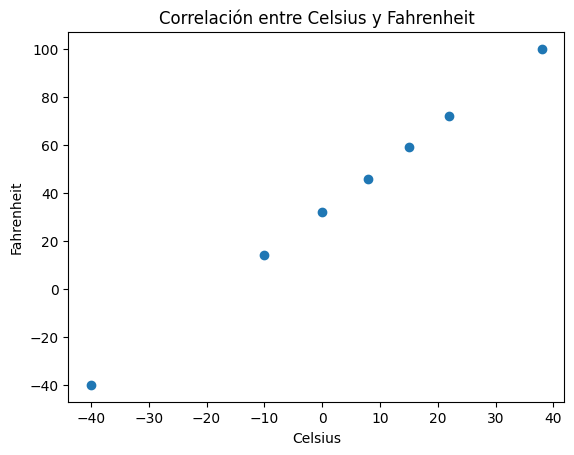

In [4]:
plt.scatter(celsius, fahrenheit)
plt.title('Correlación entre Celsius y Fahrenheit')
plt.xlabel('Celsius')
plt.ylabel('Fahrenheit')
plt.show()

In [5]:
X_train = celsius
Y_train = fahrenheit

In [6]:
print('Creando el modelo')
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape = (1, )))
model.add(tf.keras.layers.Dense(units = 1))

Creando el modelo


2026-03-05 16:58:19.225302: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
print('Compilando el modelo')
model.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

Compilando el modelo


In [8]:
print('Entrenando el modelo')
epochs_hist = model.fit(X_train, Y_train, epochs = 100)

Entrenando el modelo
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - loss: 1752.7684
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 935.5610
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1070.1305
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1214.3474
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1036.2784
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 783.0116
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 653.7271
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 673.6968
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 724.6447
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 695.2428
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 585.0587
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 464.1988
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 395.8470
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 389.9852
Epoch 15/100
1/1 ━━━━━━━━━━━━━━

Evaluando el modelo entrenado
keys:  dict_keys(['loss'])


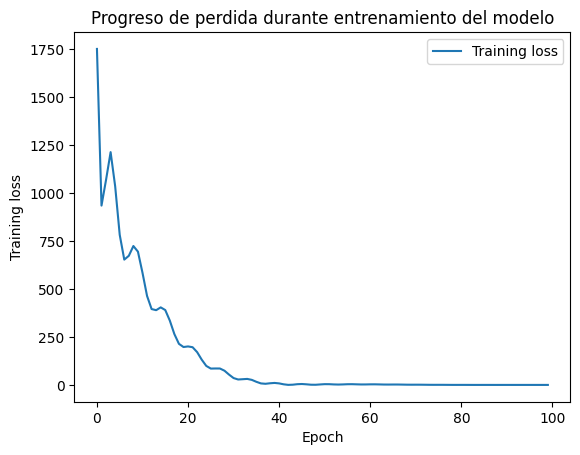

In [9]:
print('Evaluando el modelo entrenado')
print('keys: ', epochs_hist.history.keys())

# Grafico 
plt.plot(epochs_hist.history['loss'])
plt.title('Progreso de perdida durante entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

In [10]:
# Realizar una predicción utilizando el modelo entrenado
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)

'''
Resultado utilizando la fórmula matemática, para corroborar qué tan cercana 
fue la predicción que el modelo arrojó.
'''

Temp_F_ecuacion = 9/5 * Temp_C + 32

print('Temperatura de predicción: ' + str(Temp_F))
print('Temperatura de ecuación: ' + str(Temp_F_ecuacion))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Temperatura de predicción: [[212.20477]]
Temperatura de ecuación: 212.0


# Celsius a Fahrenheit (modificado)

In [11]:
df_temperatura = pd.read_csv('./celsius_a_fahrenheit.csv')
df_temperatura.head()

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

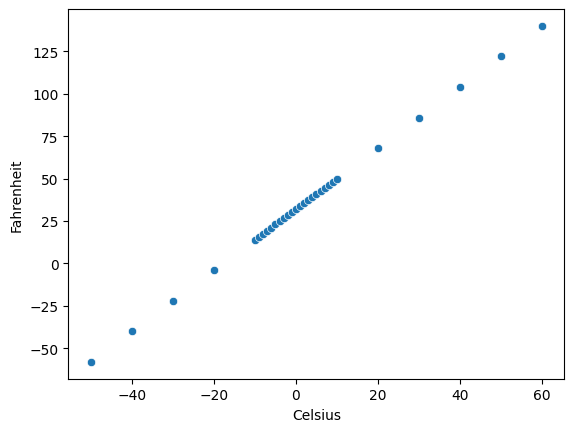

In [12]:
# Mostrando la correlación de los datos
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)

In [14]:
X_train_modify = df_temperatura['Celsius']
Y_train_modify = df_temperatura['Fahrenheit']

In [15]:
epochs_hist_modify = model.fit(X_train_modify, Y_train_modify, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.0648
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0578
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0557
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0566
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0538
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0462
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0392
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0360
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0338
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0290
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0225
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0179
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0159
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0138
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0101
Epoch 16/100
1/1 ━

In [16]:
print('Creando el modelo [modificado]')
model_modify = tf.keras.Sequential()
model_modify.add(tf.keras.layers.Input(shape = (1, )))
model_modify.add(tf.keras.layers.Dense(units = 1))

Creando el modelo [modificado]


Evaluando el modelo entrenado [Modificado]
keys:  dict_keys(['loss'])


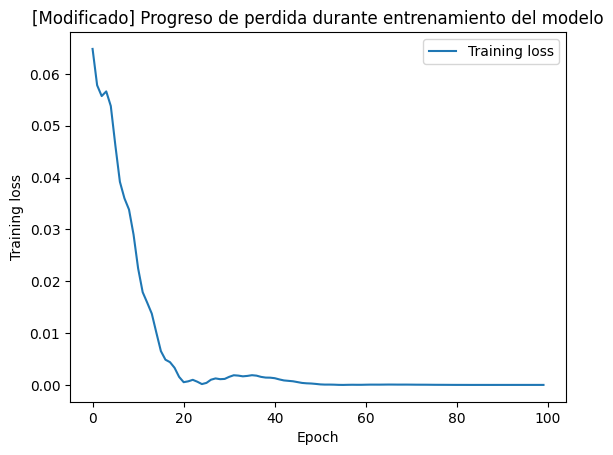

In [18]:
print('Evaluando el modelo entrenado [Modificado]')
print('keys: ', epochs_hist_modify.history.keys())

# Grafico 
plt.plot(epochs_hist_modify.history['loss'])
plt.title('[Modificado] Progreso de perdida durante entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

In [22]:
# Agregando dos capas mas
model.add(tf.keras.layers.Dense(units = 1))
model.add(tf.keras.layers.Dense(units = 1))
epochs_hist_modify = model.fit(X_train_modify, Y_train_modify, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.3480e-06
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.2726e-06
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.9060e-06
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.4818e-06
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.2962e-06
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1505e-06
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 8.4325e-07
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 5.6041e-07
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 4.6303e-07
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 3.8585e-07
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 2.1404e-07
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 9.0862e-08
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 9.3169e-08
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 8.8487e-08
Epoch 15/100
1/1 ━━━━━━━━━━━━

Evaluando el modelo entrenado [Modificado]
keys:  dict_keys(['loss'])


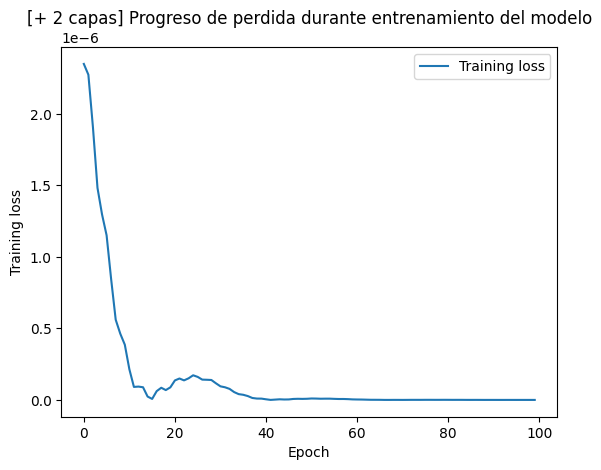

In [23]:
print('Evaluando el modelo entrenado [Modificado]')
print('keys: ', epochs_hist_modify.history.keys())

# Grafico 
plt.plot(epochs_hist_modify.history['loss'])
plt.title('[+ 2 capas] Progreso de perdida durante entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

In [36]:
# Añadiendo dos capas ocultas y una de salida
oculta1 = tf.keras.layers.Dense(units = 3, input_shape = [1])
oculta2 = tf.keras.layers.Dense(units = 3)
salida = tf.keras.layers.Dense(units = 1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])
modelo.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

epochs_hist_modify = modelo.fit(X_train_modify, Y_train_modify, epochs = 1000)

[array([[ 0.01267374,  0.3973595 , -0.18876314]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.61973166,  0.46911573,  0.19644356],
       [ 0.85787034,  0.42108226,  0.8960042 ],
       [ 0.03881288,  0.51665115, -0.11714673]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.9582695 ],
       [ 0.16027963],
       [ 0.25983322]], dtype=float32), array([0.], dtype=float32)]
Epoch 1/1000


/home/miguel/Escritorio/Octavo semestre/venv_proc_int/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step - loss: 3304.9644
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 4752.4229
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 54540.7930
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 1684.1567
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 857.2347
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1205.7825
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 1057.7283
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1250.6582
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 2648.8843
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 21360.2949
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 845.7704
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 19552.4883
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11260.6602
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 15936.6221
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━

Evaluando el modelo entrenado [Modificado]
keys:  dict_keys(['loss'])


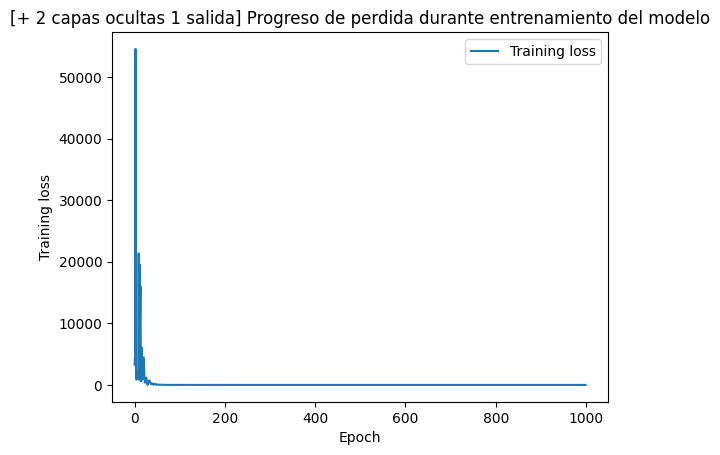

In [37]:
print('Evaluando el modelo entrenado [Modificado]')
print('keys: ', epochs_hist_modify.history.keys())

# Grafico 
plt.plot(epochs_hist_modify.history['loss'])
plt.title('[+ 2 capas ocultas 1 salida] Progreso de perdida durante entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

In [38]:
# Usando ReLU
oculta1 = tf.keras.layers.Dense(units = 3, activation = 'relu', input_shape = [1])
oculta2 = tf.keras.layers.Dense(units = 3, activation = 'relu')
salida = tf.keras.layers.Dense(units = 1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])
modelo.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

epochs_hist_modify = modelo.fit(X_train_modify, Y_train_modify, epochs = 1000)

[array([[-0.07553804,  0.6349752 , -0.5815651 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.35838437, -0.8255391 , -0.7438741 ],
       [-0.8206103 ,  0.6248176 ,  0.05363703],
       [-0.48811245, -0.9152899 ,  0.65936613]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.23798859],
       [-0.70026827],
       [ 0.6018691 ]], dtype=float32), array([0.], dtype=float32)]
Epoch 1/1000


/home/miguel/Escritorio/Octavo semestre/venv_proc_int/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step - loss: 3405.5457
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 2824.7375
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 2754.4766
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 2688.4993
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 2624.6477
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 2562.9441
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 2503.4084
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 2446.0598
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 2390.9119
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 2337.9758
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 2287.2563
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2238.7551
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 2192.4690
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2148.3887
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━

Evaluando el modelo entrenado [Modificado]
keys:  dict_keys(['loss'])


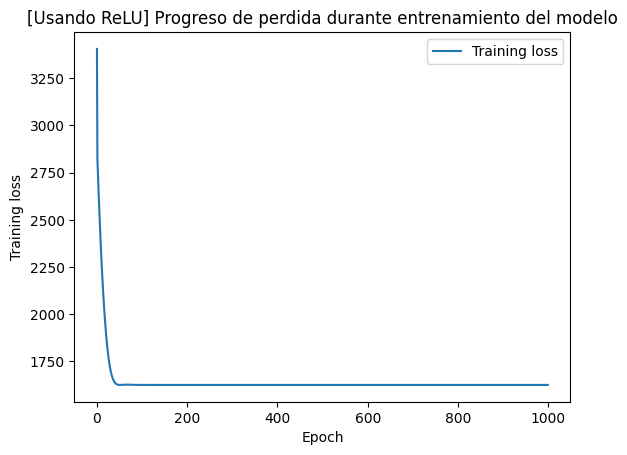

In [39]:
print('Evaluando el modelo entrenado [Modificado]')
print('keys: ', epochs_hist_modify.history.keys())

# Grafico 
plt.plot(epochs_hist_modify.history['loss'])
plt.title('[Usando ReLU] Progreso de perdida durante entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

## Preguntas

1. El optimizador de algoritmo utilizado es **Adam**, pero existen otros como **SGD** y **RMSProp**, describe cada uno de ello y explica como pudieran cambiar los resultados de tu modelo.

- Adam: Combina las ventajas de Momentum y RMSprop para ajustar los ratios de aprendizaje en el entrenamiento. Trabaja bien con datasets largos y es eficiente en memoria, tambien se adapta al ratio de aprendizaje para cada parametro. En este caso, funciona correctamente aun que seria demasiado dado a que no se está trabajando con una cantidad grande de datos. 

- SGD (Stochastic Gradient Descent): Se usa para trabajar con grandes datos, y es una variación del descenso por gradiente, además ofrece escalabilidad y eficiencia en el modelo. A pesar de que usualmente se suele trabajar con largos datasets, este algoritmo de optimización podría ser útil dado a que este dataset no contiene una cantidad de datos grandes y por lo cual podría aplicarse sin complicaciones el Stochastic Gradient Descent, dado a que el gradiente es calculado en cada entrenamiento que a comparación de usar todo el conjunto del dataset.

- RMSProp: Modifica el descenso por gradiente mediante adaptando el ratio de aprendizaje para cada parámetro basado en la magnitud de los gradientes recientes. Este algoritmo podría cambiar o reducir las épocas necesarias dado que, reduce las oscilaciones en las gráficas dado los gradientes.  


2. Describe porque es importante agregar una función de pérdida como 'mean_squared_error ', investiga que otra función de pérdida se puede implementar y como alteraría los resultados.

    El Error Cuadrático Medio es una métrica importante a añadir debido a que esto proporciona al modelo poder notar las diferencias en las predicciones que se efectúan y los valores reales. Además que penaliza los valores grandes y pequeños. 

    Otra función de pérdida que existe es la de el Error logarítmico cuadrático medio (EMC), está función ayuda a no penalizar de una manera drástica a los datos exponenciales para datos grandes, sin embargo la penalización aumenta en los valores pequeños a un gran coste.


3. En las modificaciones realizadas,  cuantas epocas fueron 'suficientes' para que el modelo se considere **entrenado** para ponerlo en funcionamiento.
¿Por qué son importantes las epoch?

    Para la última modificación (2 capas ocultas y una de salida) fueron necesarias 1000 épocas para que se notara una estabilización en el gráfico. Las épocas son necesarias e importantes dado que, hace referencia a cuántas veces el modelo se ejecutará a traves de todo el conjunto de datos para que en cada repetición tener un ajuste cada vez más preciso que el anterior. 

4. Que función de activación utiliza el modelo? ¿Es posible cambiarla? Si es así, cambia a una función RELU y muestra el resultado.

    Si es posible cambiar el modo de activación del modelo. En la última modificación se pudo apreciar que con la activación ReLU la gráfica ya se ve completamente estable lo cual quiere decir que implementando la activación ReLU, proporciona un resultado más preciso como se puede apreciar en la gráfica.
